<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/PCA_Dataset_IRIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

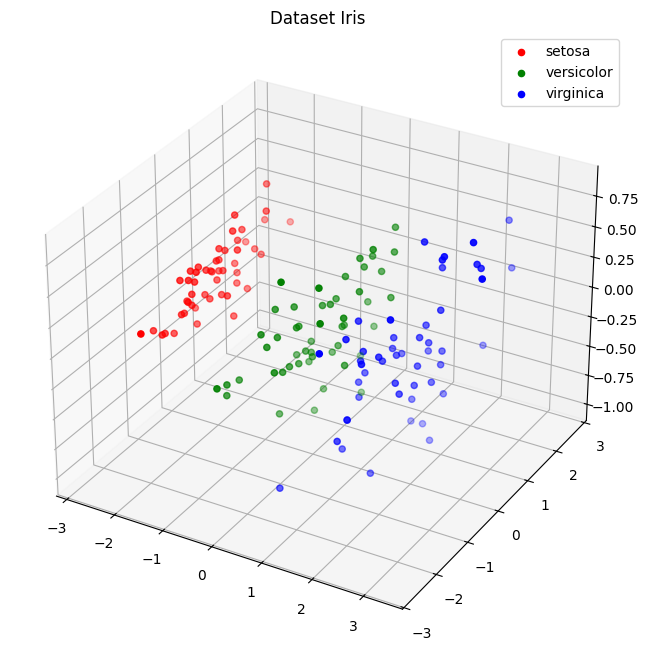

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA with 3 components
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Create a DataFrame for the 3D PCA results
pca_df_3d = pd.DataFrame(
    X_pca_3d,
    columns=['PC1', 'PC2', 'PC3']
)
pca_df_3d['Clase'] = y

# Create the 3D scatter plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

colores = ['red', 'green', 'blue']

for i, color in enumerate(colores):
    ax.scatter(
        pca_df_3d[pca_df_3d['Clase'] == i]['PC1'],
        pca_df_3d[pca_df_3d['Clase'] == i]['PC2'],
        pca_df_3d[pca_df_3d['Clase'] == i]['PC3'],
        c=color,
        label=iris.target_names[i]
    )

ax.set_title('Dataset Iris')
ax.legend()
plt.grid(True)
plt.show()

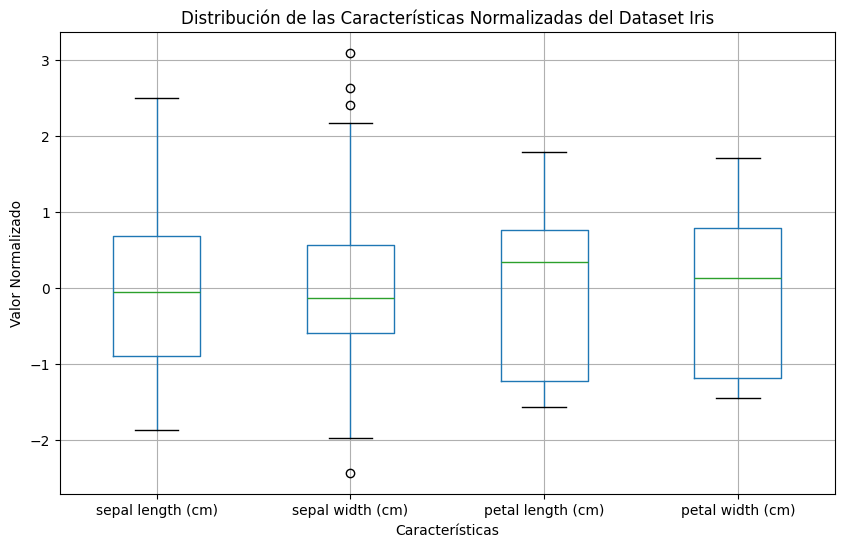

In [2]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=iris.feature_names)

plt.figure(figsize=(10, 6))
df_scaled.boxplot()
plt.title('Distribución de las Características Normalizadas del Dataset Iris')
plt.xlabel('Características')
plt.ylabel('Valor Normalizado')
plt.grid(True)
plt.show()

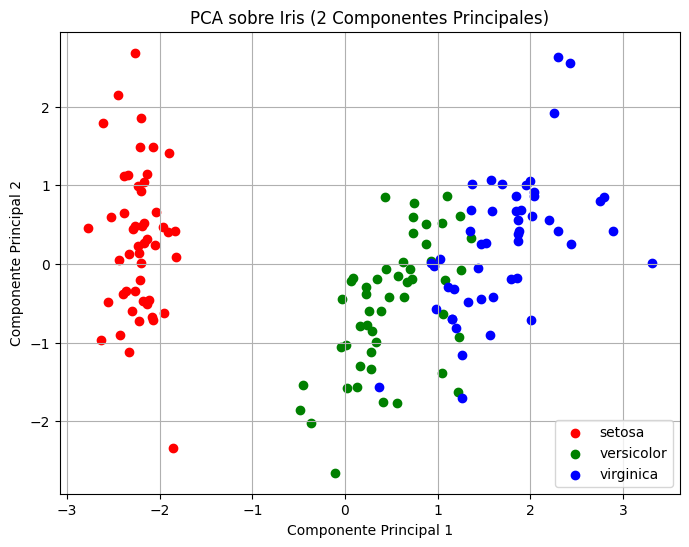

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Iris dataset (if not already loaded)
iris = load_iris()
X = iris.data
y = iris.target

# Scale data (if not already scaled)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)
pca_df['Clase'] = y

plt.figure(figsize=(8,6))
colores = ['red','green','blue']

for i, color in enumerate(colores):
    plt.scatter(
        pca_df[pca_df['Clase']==i]['PC1'],
        pca_df[pca_df['Clase']==i]['PC2'],
        c=color,
        label=iris.target_names[i]
    )
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA sobre Iris (2 Componentes Principales)')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
print("Varianza explicada:")

print(pca.explained_variance_ratio_)

print("Varianza acumulada:")

print(sum(pca.explained_variance_ratio_))

Varianza explicada:
[0.72962445 0.22850762]
Varianza acumulada:
0.9581320720000166


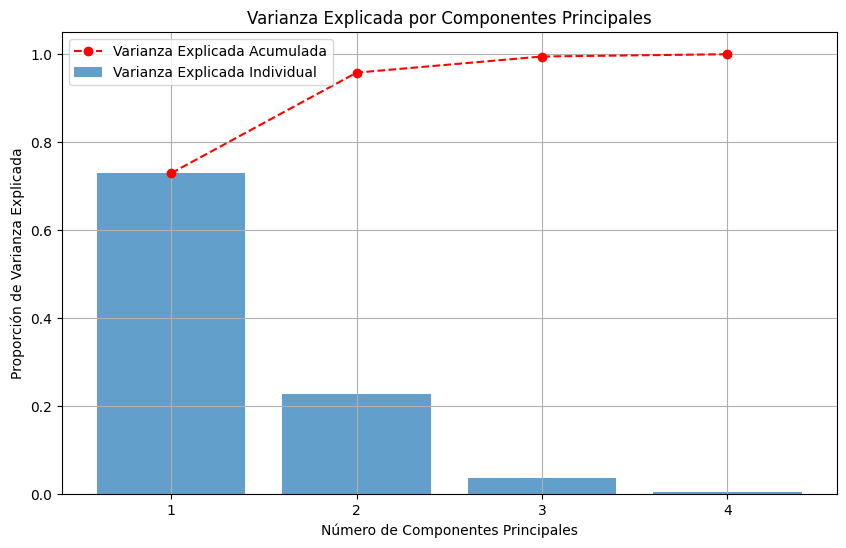

Varianza explicada por cada componente:
PC1: 0.7296
PC2: 0.2285
PC3: 0.0367
PC4: 0.0052

Varianza acumulada hasta 4 componentes: 1.0000


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure pca object is available. If not, re-run PCA.
# This assumes `pca` was previously defined, e.g., for 2 components.
# If a new PCA is needed, it should be created here.
# For this plot, we will use the 3-component PCA already performed (pca_3d)
# and illustrate how to get variance for any number of components.

# Let's re-run PCA for up to 4 components to show all variance
pca_all = PCA()
pca_all.fit(X_scaled)

explained_variance_ratio = pca_all.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

components = range(1, len(explained_variance_ratio) + 1)

plt.figure(figsize=(10, 6))
plt.bar(components, explained_variance_ratio, alpha=0.7, align='center', label='Varianza Explicada Individual')
plt.plot(components, cumulative_variance, marker='o', linestyle='--', color='red', label='Varianza Explicada Acumulada')

plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza Explicada')
plt.title('Varianza Explicada por Componentes Principales')
plt.xticks(components)
plt.legend()
plt.grid(True)
plt.show()

print("Varianza explicada por cada componente:")
for i, var in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {var:.4f}")

print(f"\nVarianza acumulada hasta 4 componentes: {cumulative_variance[-1]:.4f}")